In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
branches = pd.read_csv("../data/branches_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")

In [6]:
branch_disbursement = branches.sort_values(
    by='Loan_Disbursement_Amount',
    ascending=False
)

branch_disbursement[['Branch_ID', 'Region', 'Loan_Disbursement_Amount']].head()

,Branch_ID,Region,Loan_Disbursement_Amount
35,B036,East,499562869
13,B014,North,482327541
11,B012,West,465469874
47,B048,Central,464419943
34,B035,Central,449109596


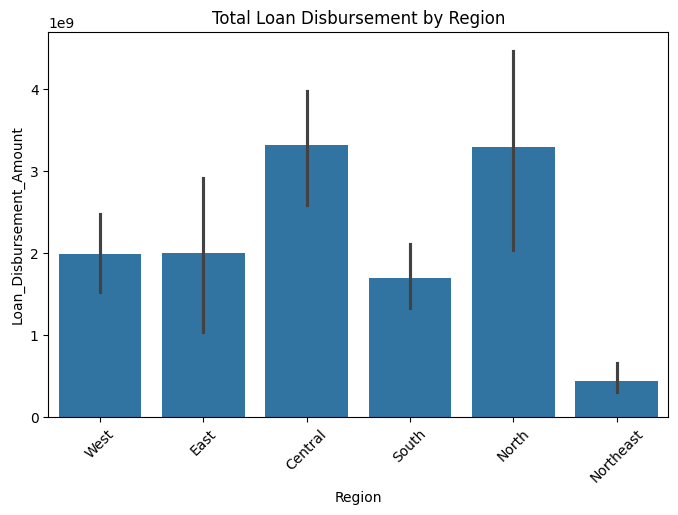

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Region',
    y='Loan_Disbursement_Amount',
    data=branches,
    estimator=sum
)
plt.title("Total Loan Disbursement by Region")
plt.xticks(rotation=45)
plt.show()

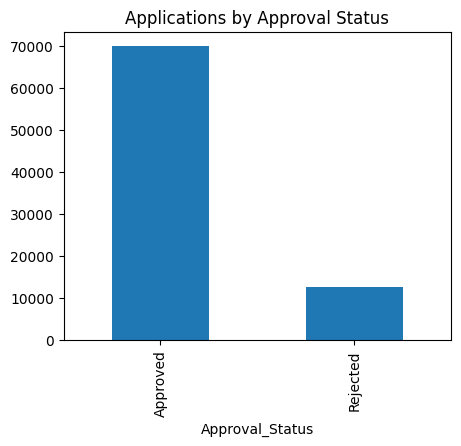

In [9]:
applications = pd.read_csv("../data/applications_cleaned.csv",low_memory=False)
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])

processing_time = applications.groupby('Approval_Status').size()

processing_time.plot(kind='bar', figsize=(5,4))
plt.title("Applications by Approval Status")
plt.show()

In [10]:
branches['Default_Rate'] = (
    branches['Delinquent_Loans'] / branches['Total_Active_Loans']
)

branches[['Branch_ID', 'Region', 'Default_Rate']].sort_values(
    by='Default_Rate',
    ascending=False
).head()

,Branch_ID,Region,Default_Rate
2,B003,Central,1.377049
31,B032,Northeast,0.681275
7,B008,Central,0.513158
8,B009,North,0.449153
6,B007,North,0.427350


In [11]:
defaults['Recovery_Rate'] = (
    defaults['Recovery_Amount'] / defaults['Default_Amount']
)

avg_recovery = defaults['Recovery_Rate'].mean()
avg_recovery

np.float64(0.40455751045929983)

In [12]:
region_summary = branches.groupby('Region').agg({
    'Loan_Disbursement_Amount': 'sum',
    'Delinquent_Loans': 'sum',
    'Total_Active_Loans': 'sum'
})

region_summary['Regional_Default_Rate'] = (
    region_summary['Delinquent_Loans'] /
    region_summary['Total_Active_Loans']
)

region_summary

,Loan_Disbursement_Amount,Delinquent_Loans,Total_Active_Loans,Regional_Default_Rate
Region,,,,
Central,3316048302,994,8715,0.114056
East,2006676282,756,8929,0.084668
North,3296073904,1504,11965,0.125700
Northeast,442827845,487,5174,0.094124
South,1694906506,846,9235,0.091608
West,1990828641,441,6861,0.064276


### Task 4 – Branch & Regional Performance Insights

- Certain regions dominate loan disbursement volume
- Branches with higher delinquent loan ratios show weaker recovery performance
- Regional disparities exist in default exposure
- Improving branch-level monitoring can reduce defaults and enhance efficiency